In [1]:
from utils import DATA_DIR
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(DATA_DIR)
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


# 1. Initial Analysis

Overview of dataset shape, data types, descriptive statistics, and missing values.

In [2]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nDescriptive statistics:")
df.describe()

Shape: (3276, 10)

Data types:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

Descriptive statistics:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


Missing values per column:
                 Missing Count  Missing %
ph                         491      14.99
Sulfate                    781      23.84
Trihalomethanes            162       4.95


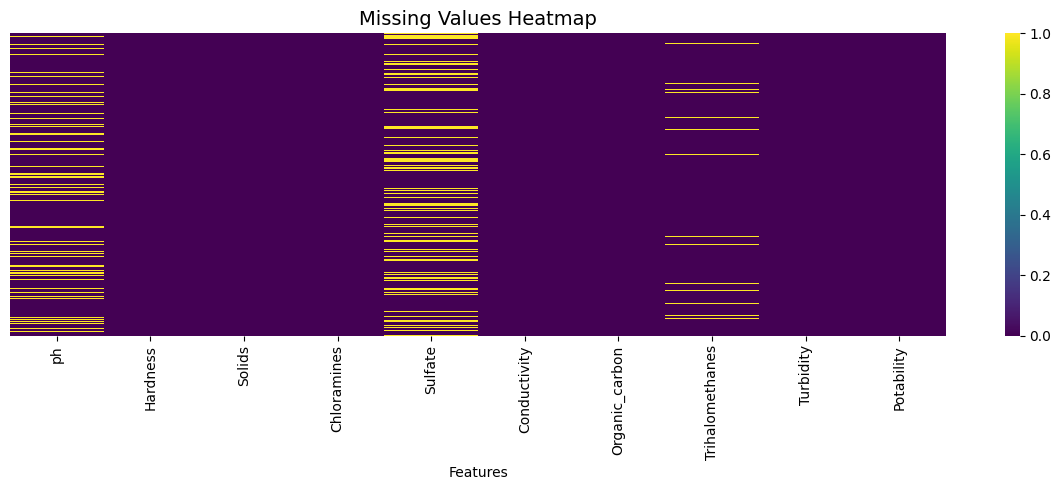

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print("Missing values per column:")
print(missing_df[missing_df["Missing Count"] > 0])

plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap", fontsize=14)
plt.xlabel("Features")
plt.tight_layout()
plt.show()

# 2. Target Distribution

The dataset is moderately imbalanced: ~61 % non-potable vs ~39 % potable.  
Using **accuracy** as the sole metric is misleading — a classifier that always predicts  
"not potable" would score ~61 %.  We will use **F1-score** and **AUC-ROC** as primary metrics.

/var/folders/kd/vq32c04j73n3rh4gd0fkj9540000gn/T/ipykernel_28466/1676822483.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Potability", data=df, palette=["#e74c3c", "#2ecc71"], ax=ax)


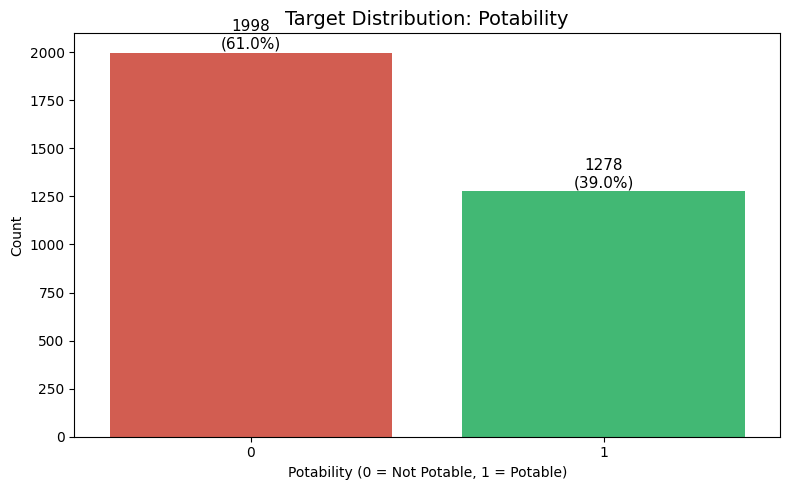

Class distribution:
  Not potable (0): 1998 samples (61.0%)
  Potable     (1): 1278 samples (39.0%)
  Imbalance ratio: 1.56:1


In [4]:
counts = df["Potability"].value_counts().sort_index()
pct = (counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
# list-based palette avoids the seaborn dict-key/int mismatch on categorical axes
sns.countplot(x="Potability", data=df, palette=["#e74c3c", "#2ecc71"], ax=ax)
ax.set_title("Target Distribution: Potability", fontsize=14)
ax.set_xlabel("Potability (0 = Not Potable, 1 = Potable)")
ax.set_ylabel("Count")

for i, (count, p) in enumerate(zip(counts, pct)):
    ax.text(i, count + 20, f"{count}\n({p}%)", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

print(f"Class distribution:")
print(f"  Not potable (0): {counts[0]} samples ({pct[0]}%)")
print(f"  Potable     (1): {counts[1]} samples ({pct[1]}%)")
print(f"  Imbalance ratio: {counts[0]/counts[1]:.2f}:1")

# 3. Feature Distributions

Distribution of each feature split by potability class.  
Heavily overlapping distributions indicate weak discriminators.

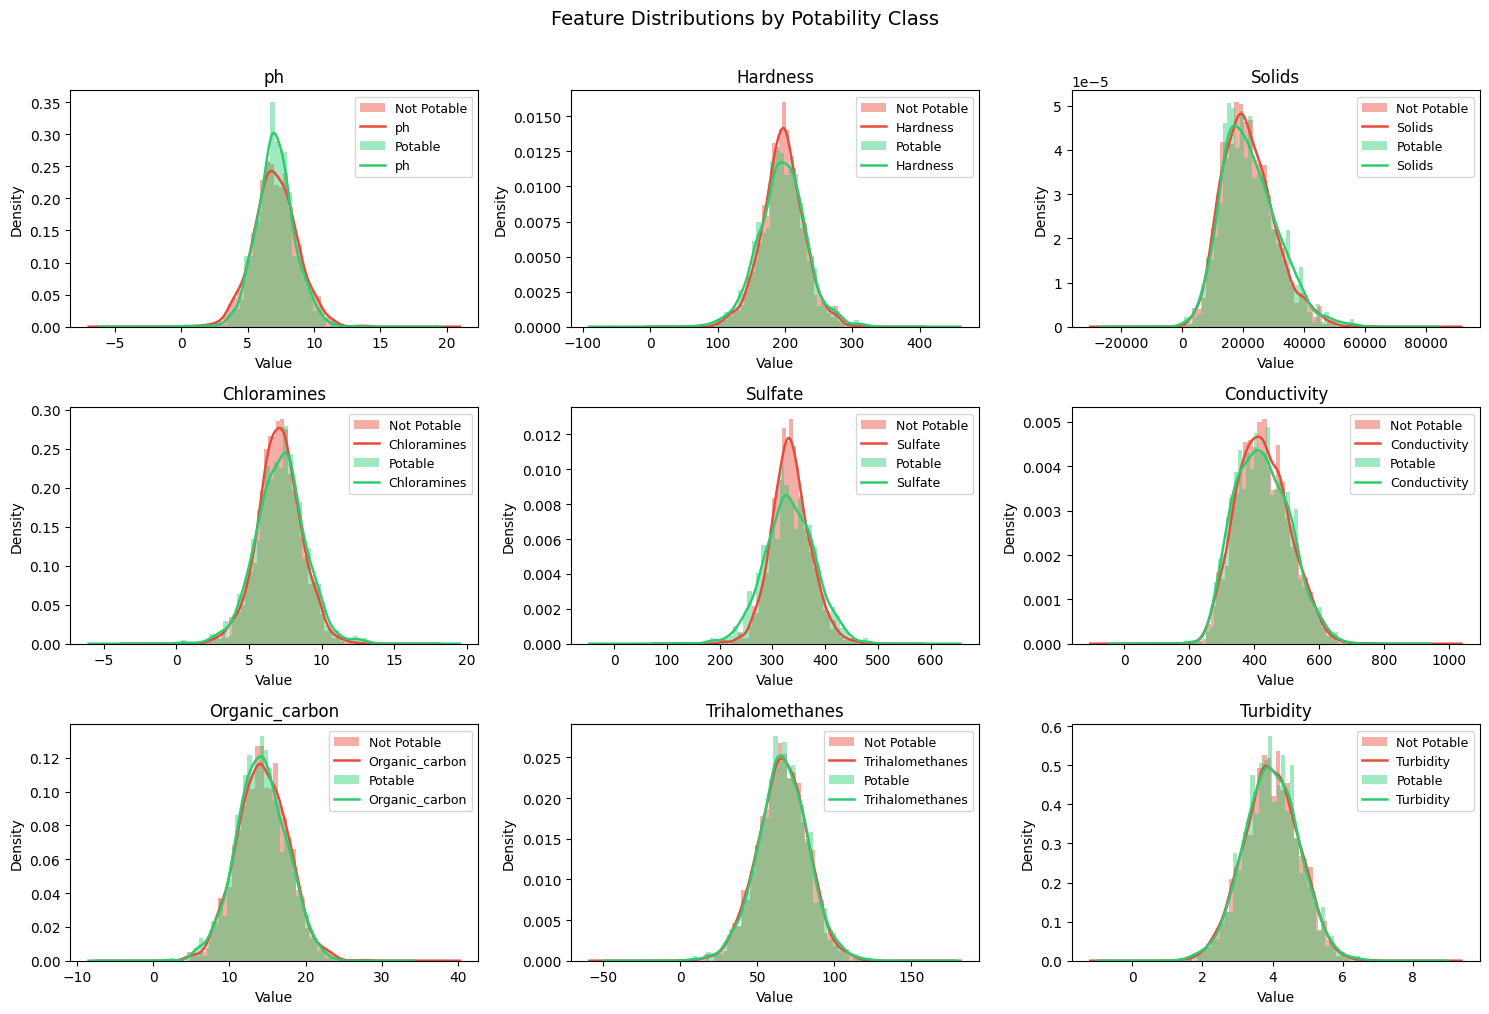

In [5]:
features = [c for c in df.columns if c != "Potability"]
colors = {0: "#e74c3c", 1: "#2ecc71"}
labels = {0: "Not Potable", 1: "Potable"}

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    for cls, color in colors.items():
        subset = df[df["Potability"] == cls][feat].dropna()
        axes[i].hist(subset, bins=40, alpha=0.45, color=color,
                     label=labels[cls], density=True)
        subset.plot.kde(ax=axes[i], color=color, linewidth=1.8)
    axes[i].set_title(feat, fontsize=12)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=9)

plt.suptitle("Feature Distributions by Potability Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 4. Correlation Analysis

Pairwise Pearson correlations between all features and the target.  
Low correlations (all |r| < 0.1) confirm this is a hard classification problem —  
no single feature strongly predicts potability.

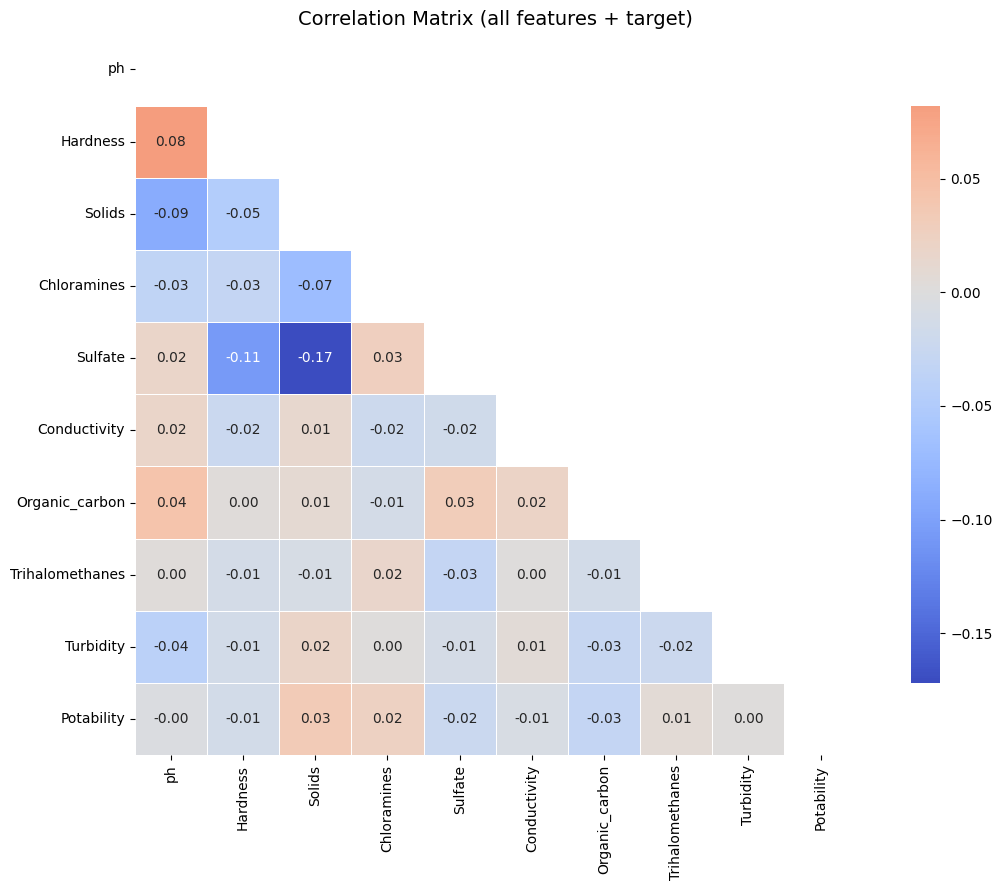

Correlations with target (Potability):
Solids             0.033743
Organic_carbon    -0.030001
Chloramines        0.023779
Sulfate           -0.023577
Hardness          -0.013837
Conductivity      -0.008128
Trihalomethanes    0.007130
ph                -0.003556
Turbidity          0.001581
Name: Potability, dtype: float64


In [6]:
corr = df.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix (all features + target)", fontsize=14)
plt.tight_layout()
plt.show()

print("Correlations with target (Potability):")
print(corr["Potability"].drop("Potability").sort_values(key=abs, ascending=False))

# 5. Boxplots by Class

Median and spread per feature for each class.  
Features whose medians differ visibly between classes are stronger discriminators.

/var/folders/kd/vq32c04j73n3rh4gd0fkj9540000gn/T/ipykernel_28466/2855065581.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Potability", y=feat, data=df,
/var/folders/kd/vq32c04j73n3rh4gd0fkj9540000gn/T/ipykernel_28466/2855065581.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Potability", y=feat, data=df,
/var/folders/kd/vq32c04j73n3rh4gd0fkj9540000gn/T/ipykernel_28466/2855065581.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Potability", y=feat, data=df,
/var/folders/kd/vq32c04j73n3rh4gd0fkj9540000gn/T/ipykernel_28466

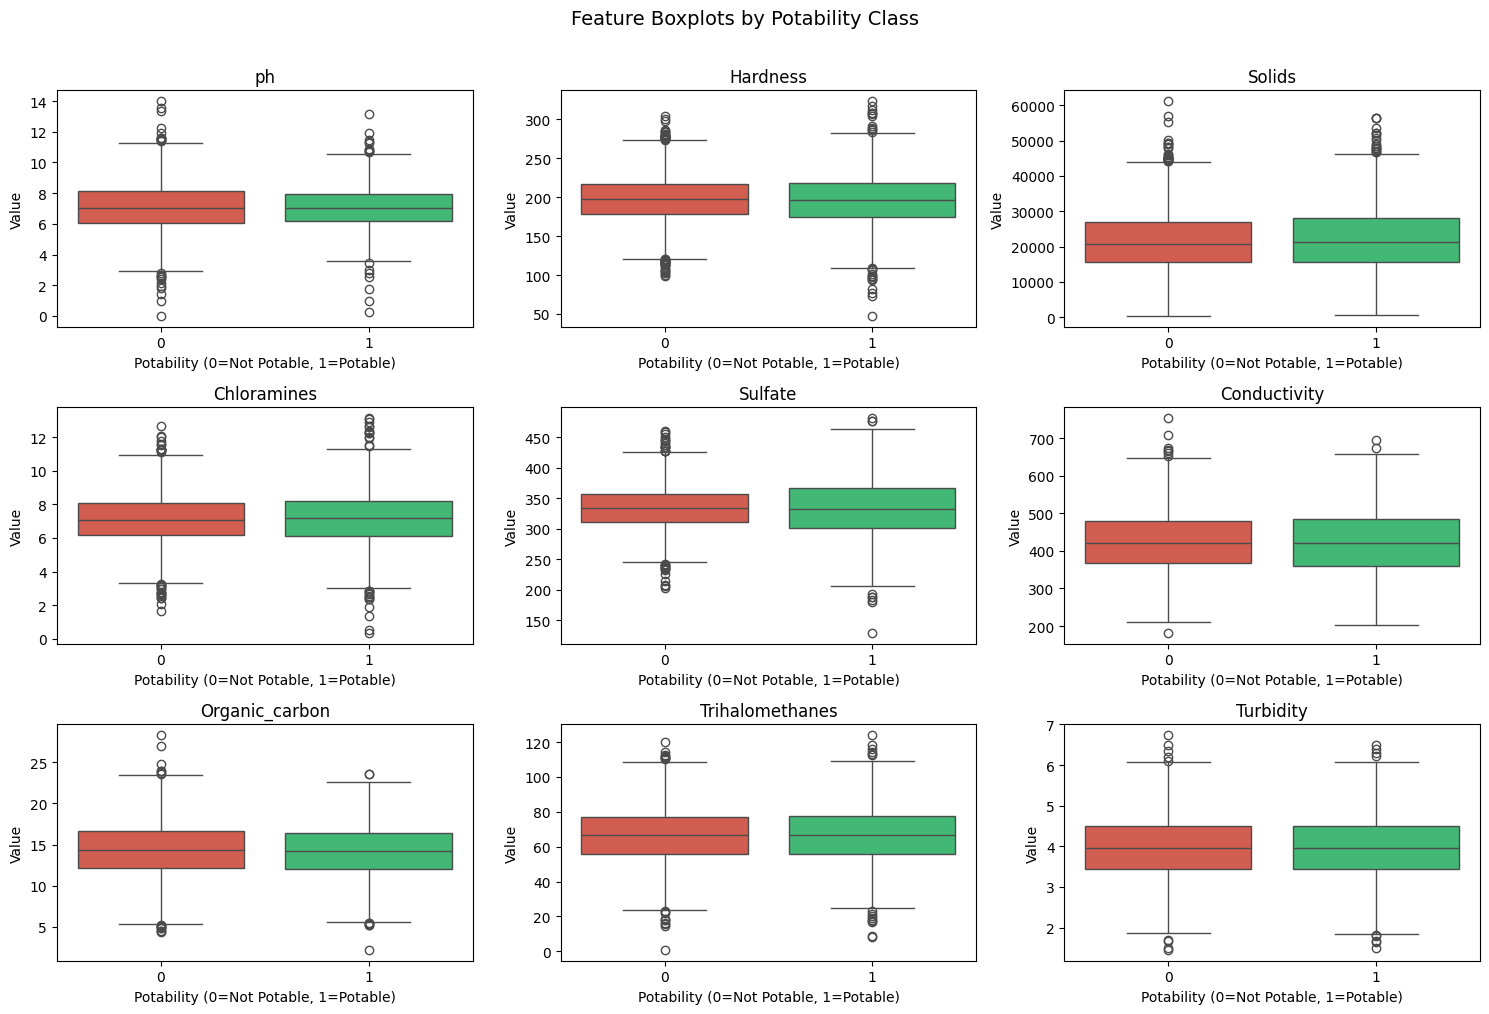

In [7]:
features = [c for c in df.columns if c != "Potability"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(x="Potability", y=feat, data=df,
                palette=["#e74c3c", "#2ecc71"], ax=axes[i])
    axes[i].set_title(feat, fontsize=12)
    axes[i].set_xlabel("Potability (0=Not Potable, 1=Potable)")
    axes[i].set_ylabel("Value")

plt.suptitle("Feature Boxplots by Potability Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 6. Missing Values — Imputation Strategy

Three columns contain missing values:
- **ph**: 491 missing (~15 %)
- **Sulfate**: 781 missing (~24 %)
- **Trihalomethanes**: 162 missing (~5 %)

**Strategy: Median imputation** via `SimpleImputer(strategy="median")`.  
Median is preferred over mean because it is robust to the outliers present in this dataset.

> In production the imputer is fitted on the training set only (inside a `Pipeline`) to prevent data leakage.  
> Here we impute the full dataset for exploration purposes.

In [8]:
from sklearn.impute import SimpleImputer

print("Missing values BEFORE imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

imputer = SimpleImputer(strategy="median")
df_imputed = df.copy()
df_imputed[df.columns] = imputer.fit_transform(df)

print("\nMissing values AFTER imputation:", df_imputed.isnull().sum().sum(), "remaining")
df_imputed.describe()

Missing values BEFORE imputation:
ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64

Missing values AFTER imputation: 0 remaining


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,7.074194,196.369496,22014.092526,7.122277,333.608364,426.205111,14.284970,66.407478,3.966786,0.390110
std,1.470040,32.879761,8768.570828,1.583085,36.143851,80.824064,3.308162,15.769958,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.277673,176.850538,15666.690297,6.127421,317.094638,365.734414,12.065801,56.647656,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,7.870050,216.667456,27332.762127,8.114887,350.385756,481.792304,16.557652,76.666609,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


# 7. Outlier Detection

Visualising extreme values on key features.  
`Solids` and `Conductivity` are expected to show the most notable outliers.

**Decision: keep outliers.**  
- They may represent real-world extreme water conditions.  
- Tree-based models (Random Forest, XGBoost) are naturally robust to them.  
- Removing them could introduce bias when computing median imputation.

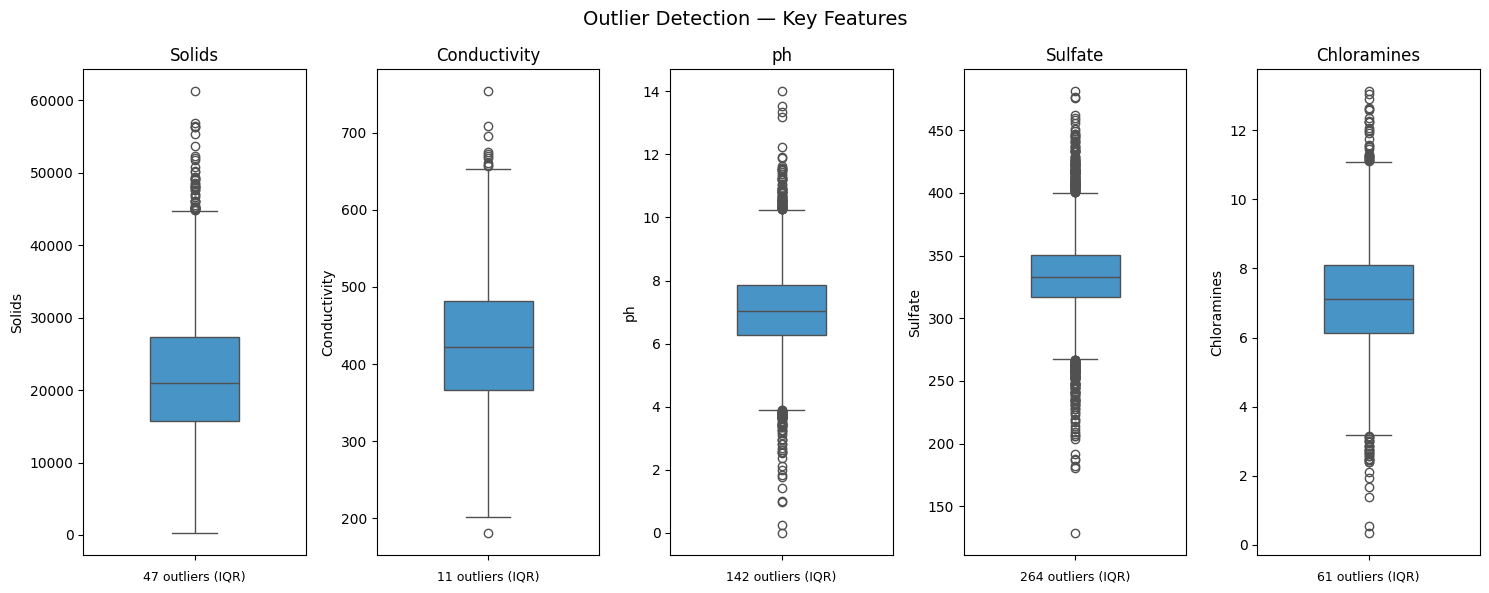

In [9]:
features_to_check = ["Solids", "Conductivity", "ph", "Sulfate", "Chloramines"]

fig, axes = plt.subplots(1, len(features_to_check), figsize=(15, 6))

for i, feat in enumerate(features_to_check):
    sns.boxplot(y=df_imputed[feat], ax=axes[i], color="#3498db", width=0.4)
    axes[i].set_title(feat, fontsize=12)

    q1, q3 = df_imputed[feat].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df_imputed[feat] < q1 - 1.5 * iqr) |
             (df_imputed[feat] > q3 + 1.5 * iqr)).sum()
    axes[i].set_xlabel(f"{n_out} outliers (IQR)", fontsize=9)

plt.suptitle("Outlier Detection — Key Features", fontsize=14)
plt.tight_layout()
plt.show()

# 8. Conclusion — EDA Summary

## Key findings

| Finding | Detail |
|---|---|
| **Class imbalance** | ~61 % non-potable / ~39 % potable — accuracy alone is misleading |
| **Weak correlations** | All Pearson \|r\| < 0.1 — no single feature strongly predicts potability |
| **Missing values** | ph (~15 %), Sulfate (~24 %), Trihalomethanes (~5 %) — imputed with median |
| **Outliers** | Present in Solids and Conductivity — retained, tree-based models handle them |

## Recommendations for modelling

- **Metrics**: **F1-score** and **AUC-ROC** as primary metrics; avoid accuracy alone.
- **Imbalance handling**: `class_weight="balanced"` or SMOTE oversampling.
- **Models**: tree-based ensembles (Random Forest, XGBoost, LightGBM) as first choice.
- **Pipeline**: wrap `SimpleImputer` in a `Pipeline` to prevent data leakage in CV.
- **Baseline**: `DummyClassifier` at ~61 % sets the floor — any useful model must beat it on F1/AUC.